# Positive Count as a Driver of Synthetic Data Fidelity: A Controlled Simulation

In [1]:
library(synthpop)
library(dplyr)
library(ggplot2)
library(tidyr)

New version of synthpop (1.9-0) with disclosure functions
see disclosure.pdf for details and NEWS file for other changes

Find out more at https://www.synthpop.org.uk/


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Population & Ground Truth

In [2]:
EXPLODE_THRESHOLD <- 10

generate_population <- function(effect_size, N = 5000, seed = 42) {
  set.seed(seed)
  pop <- data.frame(
    age     = rnorm(N, 65, 15),
    lactate = rnorm(N, 2, 1),
    chf     = rbinom(N, 1, 0.08)
  )
  # DGP: chf:lactate true value = effect_size, only in the CHF=1 stratum
  logit_p <- -3 + 0.02*pop$age + 0.3*pop$lactate +
             pop$chf*(2 + effect_size*pop$lactate)
  pop$mortality <- rbinom(N, 1, plogis(logit_p))
  pop
}

## Functions

### Helper Function: get_interaction()

In [3]:
get_interaction <- function(df) {
  fit <- suppressWarnings(
    glm(mortality ~ age + lactate + chf + chf:lactate,
        data = df, family = binomial)
  )
  coef(fit)["lactate:chf"]
}

### Trial Function: run_one_trial()

In [4]:
run_one_trial <- function(k, seed, n_fixed, pos_pool, neg_pool) {
  set.seed(seed)

  sub <- rbind(pos_pool[sample(nrow(pos_pool), k), ],
               neg_pool[sample(nrow(neg_pool), n_fixed - k), ])

  # cast binaries to factor so synthpop treats them as categorical
  sub$chf       <- factor(sub$chf)
  sub$mortality <- factor(sub$mortality)

  syn_obj <- syn(sub, seed = seed, print.flag = FALSE)
  syn     <- syn_obj$syn

  # cast back to numeric for the glm probe (factor coding renames the
  # interaction term to "lactate:chf1", which breaks coef(fit)["lactate:chf"])
  sub$chf       <- as.numeric(as.character(sub$chf))
  sub$mortality <- as.numeric(as.character(sub$mortality))
  syn$chf       <- as.numeric(as.character(syn$chf))
  syn$mortality <- as.numeric(as.character(syn$mortality))

  real_est <- get_interaction(sub)
  syn_est  <- get_interaction(syn)

  data.frame(
    count         = k,
    rep           = seed,
    real_est      = real_est,
    syn_est       = syn_est,
    real_exploded = abs(real_est) > EXPLODE_THRESHOLD,
    syn_exploded  = abs(syn_est)  > EXPLODE_THRESHOLD
  )
}

## Robustness Sweep: Effect Size × Positive Count × Monte Carlo Replicate

In [ ]:
EFFECT_SIZES <- c(0.5, 1.5, 3)
counts       <- c(5, 10, 20, 40, 80, 150, 250)
n_fixed      <- 500
M            <- 50

all_results <- lapply(EFFECT_SIZES, function(eff) {
  pop <- generate_population(eff)
  pos_pool <- pop[pop$chf == 1, ]
  neg_pool <- pop[pop$chf == 0, ]

  eff_results <- lapply(counts, function(k) {
    lapply(seq_len(M), function(r) {
      run_one_trial(k, seed = k * 1000 + r, n_fixed, pos_pool, neg_pool)
    }) %>% bind_rows()
  }) %>% bind_rows()

  eff_results$effect_size <- eff
  eff_results$true        <- eff
  eff_results
}) %>% bind_rows()

all_results$real_error <- abs(all_results$real_est - all_results$true)
all_results$syn_error  <- abs(all_results$syn_est  - all_results$true)

summary_df <- all_results %>%
  group_by(effect_size, count) %>%
  summarise(
    real_pct_exploded  = round(100 * mean(real_exploded, na.rm = TRUE), 1),
    syn_pct_exploded   = round(100 * mean(syn_exploded,  na.rm = TRUE), 1),
    # median computed only among non-exploded runs — "typical" behavior
    # when the fit actually converges, separate from how OFTEN it doesn't
    real_median        = median(real_est[!real_exploded], na.rm = TRUE),
    syn_median         = median(syn_est[!syn_exploded],   na.rm = TRUE),
    real_error_median  = median(real_error[!real_exploded], na.rm = TRUE),
    syn_error_median   = median(syn_error[!syn_exploded],   na.rm = TRUE),
    .groups = "drop"
  )
print(summary_df, n = Inf)

# A tibble: 21 × 8
   effect_size count real_pct_exploded syn_pct_exploded real_median syn_median
         <dbl> <dbl>             <dbl>            <dbl>       <dbl>      <dbl>
 1         0.5     5                30               18     -0.127     -0.0812
 2         0.5    10                14               16      0.178     -0.378 
 3         0.5    20                 0                4      0.295     -0.355 
 4         0.5    40                 0                2      0.460     -0.197 
 5         0.5    80                 0                0      0.429      0.286 
 6         0.5   150                 0                0      0.397      0.468 
 7         0.5   250                 0                0      0.395      0.371 
 8         1.5     5                26               16     -0.209     -0.146 
 9         1.5    10                24                8     -0.0720    -0.331 
10         1.5    20                14                4      0.829     -0.284 
# ℹ 11 more rows
# ℹ 2 more varia

## Results

### Accuracy: Median Estimate vs Positive Count

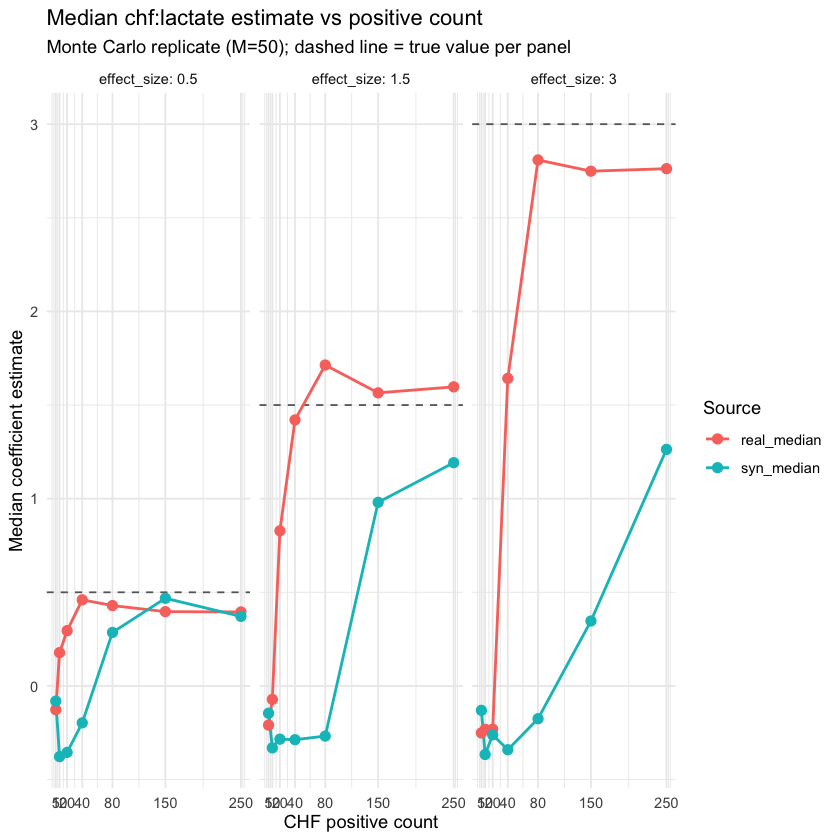

In [13]:
median_long <- summary_df %>%
  select(effect_size, count, real_median, syn_median) %>%
  pivot_longer(c(real_median, syn_median), names_to = "source", values_to = "coef")

hline_df <- data.frame(effect_size = EFFECT_SIZES, true = EFFECT_SIZES)

ggplot(median_long, aes(count, coef, color = source)) +
  geom_hline(data = hline_df, aes(yintercept = true),
             linetype = "dashed", color = "grey40") +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2.5) +
  facet_wrap(~ effect_size, labeller = label_both) +
  scale_x_continuous(breaks = counts) +
  labs(title = "Median chf:lactate estimate vs positive count",
       subtitle = paste0("Monte Carlo replicate (M=", M, "); dashed line = true value per panel"),
       x = "CHF positive count", y = "Median coefficient estimate",
       color = "Source") +
  theme_minimal()

### Stability: Non-Convergence Rate vs Positive Count

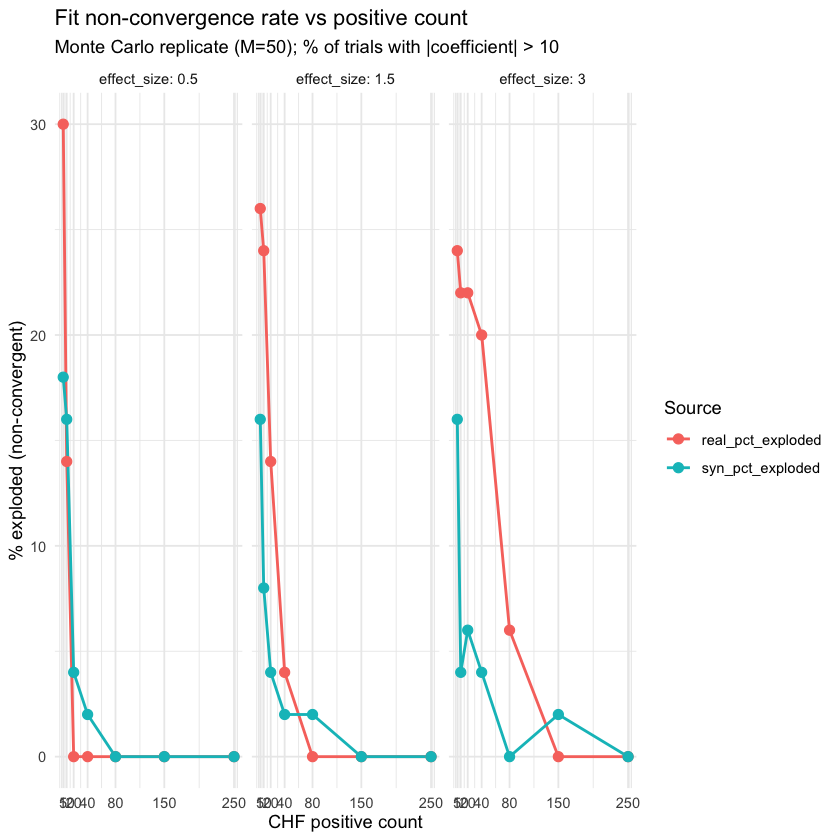

In [14]:
exploded_long <- summary_df %>%
  select(effect_size, count, real_pct_exploded, syn_pct_exploded) %>%
  pivot_longer(c(real_pct_exploded, syn_pct_exploded),
               names_to = "source", values_to = "pct_exploded")

ggplot(exploded_long, aes(count, pct_exploded, color = source)) +
  geom_line(linewidth = 0.8) + geom_point(size = 2.5) +
  facet_wrap(~ effect_size, labeller = label_both) +
  scale_x_continuous(breaks = counts) +
  labs(title = "Fit non-convergence rate vs positive count",
       subtitle = paste0("Monte Carlo replicate (M=", M, "); % of trials with |coefficient| > ", EXPLODE_THRESHOLD),
       x = "CHF positive count", y = "% exploded (non-convergent)",
       color = "Source") +
  theme_minimal()

### Stability vs Accuracy Trade-off

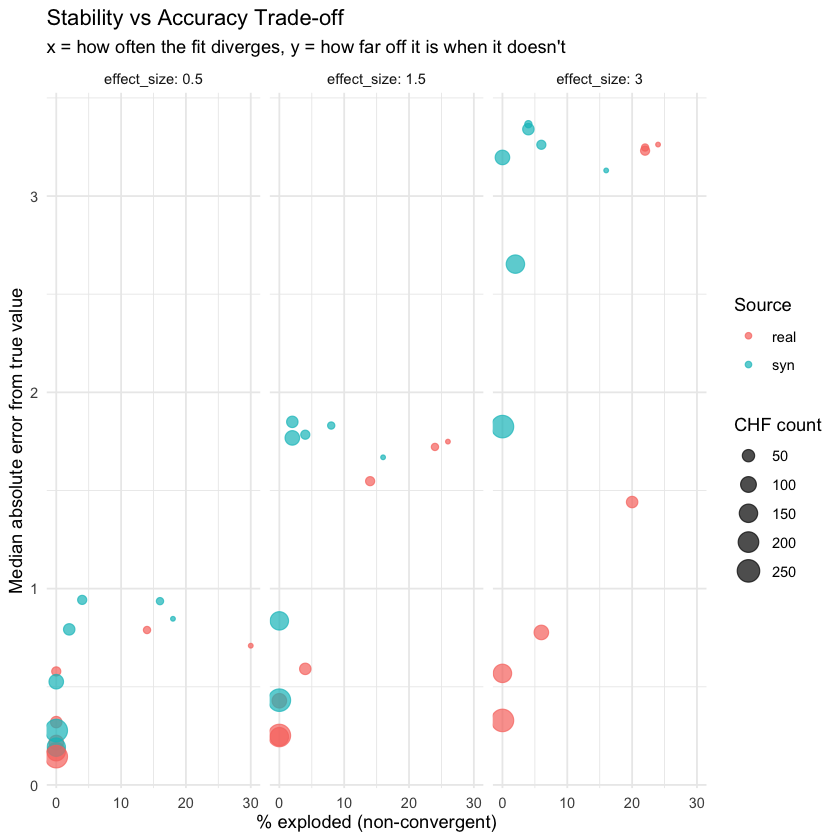

In [15]:
tradeoff_df <- summary_df %>%
  select(effect_size, count,
         real_pct_exploded, syn_pct_exploded,
         real_error_median, syn_error_median) %>%
  pivot_longer(
    cols = c(real_pct_exploded, syn_pct_exploded, real_error_median, syn_error_median),
    names_to = c("source", ".value"),
    names_pattern = "(real|syn)_(pct_exploded|error_median)"
  )

ggplot(tradeoff_df, aes(pct_exploded, error_median, color = source, size = count)) +
  geom_point(alpha = 0.7) +
  facet_wrap(~ effect_size, labeller = label_both) +
  labs(title = "Stability vs Accuracy Trade-off",
       subtitle = "x = how often the fit diverges, y = how far off it is when it doesn't",
       x = "% exploded (non-convergent)", y = "Median absolute error from true value",
       color = "Source", size = "CHF count") +
  theme_minimal()